# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ashiba713/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

The action queue ranks pages for human review using the model's estimated probability of the observed decline label.

The ranking is a prioritization aid, not an automatic decision. Each page receives reason codes based on measurable characteristics in the dataset.

The main action categories are:

- **Review refresh priority:** higher observed/modelled decline risk.
- **Review content freshness:** older content or longer time since update.
- **Review engagement:** lower observed engagement or scroll signals.
- **Monitor:** weaker or mixed signals where immediate action is not justified.

Reason codes describe why a page entered the queue. They are not causal explanations for why the page declined.

In [1]:
import os
import numpy as np
import pandas as pd

SEED = 42

# Load the same anonymized dataset used in the earlier modeling work.
df = pd.read_csv(
    "https://raw.githubusercontent.com/ashiba713/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"
)

# Observed target used throughout the capstone.
df["target_decline"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Rows:", len(df))
print("Clients:", df["client_id"].nunique())
print("Observed decline rate:", round(df["target_decline"].mean(), 4))

Rows: 30000
Clients: 32
Observed decline rate: 0.5421


In [2]:
# Features used by the Week-5 model.
feature_columns = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "days_with_impressions",
    "days_with_sessions"
]

X = df[feature_columns].copy()
y = df["target_decline"].copy()

# Recreate the Week-5 logistic model.
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=SEED
            )
        )
    ]
)

model.fit(X, y)

df["model_decline_score"] = model.predict_proba(X)[:, 1]

# Highest score = highest priority for review.
queue = df.sort_values(
    "model_decline_score",
    ascending=False
).copy()

queue["priority_rank"] = np.arange(
    1,
    len(queue) + 1
)

print(
    queue[
        [
            "priority_rank",
            "content_id",
            "model_decline_score"
        ]
    ].head(20)
)

       priority_rank            content_id  model_decline_score
18063              1  content_b08562686d22             0.861351
2016               2  content_67a766790dd2             0.856714
4167               3  content_a8864e189b2e             0.852318
11633              4  content_8f3b70ede1bc             0.851570
3626               5  content_8ede62882d0b             0.850043
4768               6  content_075f30202343             0.849581
16337              7  content_396217b0dc41             0.845466
3651               8  content_fd16e3475c29             0.844798
14952              9  content_cea950d62851             0.839553
17230             10  content_5195668f06db             0.838807
2171              11  content_d8020ed269ef             0.837616
367               12  content_a27eb2ede5e6             0.836859
15967             13  content_186489efe6f4             0.836854
22912             14  content_3dc2aa4e01dc             0.836548
27993             15  content_26d48a9805

In [3]:
# Build simple, human-readable reason codes.
# These are descriptive signals, not causal explanations.

def make_reason_codes(row):
    reasons = []

    if row["model_decline_score"] >= 0.70:
        reasons.append("high_observed_decline_risk")

    if row["content_age_days"] >= df["content_age_days"].median():
        reasons.append("older_content")

    if row["days_since_last_update"] >= df["days_since_last_update"].median():
        reasons.append("long_since_update")

    if row["engagement_rate"] < df["engagement_rate"].median():
        reasons.append("lower_engagement")

    if row["scroll_rate"] < df["scroll_rate"].median():
        reasons.append("lower_scroll_signal")

    if not reasons:
        reasons.append("mixed_or_lower_priority_signals")

    return reasons


queue["reason_codes"] = queue.apply(
    make_reason_codes,
    axis=1
)

queue["reason_codes"] = queue[
    "reason_codes"
].apply(lambda x: "; ".join(x))

# Practical action based on the ranking.
queue["recommended_action"] = np.select(
    [
        queue["model_decline_score"] >= 0.70,
        queue["model_decline_score"] >= 0.50
    ],
    [
        "human_review_refresh_priority",
        "human_review"
    ],
    default="monitor"
)

queue[
    [
        "priority_rank",
        "content_id",
        "model_decline_score",
        "recommended_action",
        "reason_codes"
    ]
].head(20)

,priority_rank,content_id,model_decline_score,recommended_action,reason_codes
18063,1,content_b08562686d22,0.861351,human_review_refresh_priority,high_observed_decline_risk; long_since_update
2016,2,content_67a766790dd2,0.856714,human_review_refresh_priority,high_observed_decline_risk; long_since_update
4167,3,content_a8864e189b2e,0.852318,human_review_refresh_priority,high_observed_decline_risk
11633,4,content_8f3b70ede1bc,0.851570,human_review_refresh_priority,high_observed_decline_risk; long_since_update
3626,5,content_8ede62882d0b,0.850043,human_review_refresh_priority,high_observed_decline_risk; long_since_update
4768,6,content_075f30202343,0.849581,human_review_refresh_priority,high_observed_decline_risk; long_since_update
16337,7,content_396217b0dc41,0.845466,human_review_refresh_priority,high_observed_decline_risk; long_since_update
3651,8,content_fd16e3475c29,0.844798,human_review_refresh_priority,high_observed_decline_risk; long_since_update
14952,9,content_cea950d62851,0.839553,human_review_refresh_priority,high_observed_decline_risk; long_since_update
17230,10,content_5195668f06db,0.838807,human_review_refresh_priority,high_observed_decline_risk; long_since_update


## 2. Intended use and limits

### Intended use

The playbook is intended for a content or SEO analyst who needs a prioritized queue for human review.

The model ranks pages using measured signals associated with the observed decline label. The highest-ranked pages can be reviewed first so that limited analyst time is focused on pages with stronger measured signals.

### Limits

This analysis is based on anonymized historical data. The model does not establish that a recommended action will improve a page.

The ranking should therefore be interpreted as **directional decision support**.

The model does not:

- predict Google's ranking algorithm;
- establish causal effects of refreshing content;
- guarantee traffic or engagement improvement;
- replace editorial or SEO judgment;
- determine whether a page should actually be changed.

Any action should be reviewed using the page's context, business importance, search intent, content quality, and other information unavailable to this dataset.

## 3. Human review + the no-go list

Every recommendation requires human review before action.

### Human review checklist

Before refreshing a page, the reviewer should check:

1. Whether the observed decline signal is meaningful rather than a temporary fluctuation.
2. Whether the page still matches the intended search intent.
3. Whether the content is outdated or incomplete.
4. Whether important business or editorial context is missing from the dataset.
5. Whether the proposed change is proportionate to the evidence.
6. Whether the page should be monitored instead of changed.

### No-go list

The system should **not** automatically:

- publish or rewrite content;
- delete pages;
- change titles or metadata;
- change internal links;
- change search strategy;
- declare a page unsuccessful;
- claim that an action will increase traffic;
- make decisions about high-impact pages without human review.

The model produces a queue for review. It does not execute the resulting actions.

In [4]:
# Display a small human-review queue.

review_queue = queue[
    [
        "priority_rank",
        "content_id",
        "model_decline_score",
        "recommended_action",
        "reason_codes",
        "content_age_days",
        "days_since_last_update",
        "engagement_rate",
        "scroll_rate"
    ]
].head(50).copy()

print("Top 50 pages for human review:")
display(review_queue)

Top 50 pages for human review:


,priority_rank,content_id,model_decline_score,recommended_action,reason_codes,content_age_days,days_since_last_update,engagement_rate,scroll_rate
18063,1,content_b08562686d22,0.861351,human_review_refresh_priority,high_observed_decline_risk; long_since_update,106,106,0.0,100.00
2016,2,content_67a766790dd2,0.856714,human_review_refresh_priority,high_observed_decline_risk; long_since_update,106,106,0.0,100.00
4167,3,content_a8864e189b2e,0.852318,human_review_refresh_priority,high_observed_decline_risk,140,8,0.0,300.00
11633,4,content_8f3b70ede1bc,0.851570,human_review_refresh_priority,high_observed_decline_risk; long_since_update,141,20,0.0,200.00
3626,5,content_8ede62882d0b,0.850043,human_review_refresh_priority,high_observed_decline_risk; long_since_update,117,20,0.0,200.00
4768,6,content_075f30202343,0.849581,human_review_refresh_priority,high_observed_decline_risk; long_since_update,92,20,0.0,100.00
16337,7,content_396217b0dc41,0.845466,human_review_refresh_priority,high_observed_decline_risk; long_since_update,106,106,0.0,50.00
3651,8,content_fd16e3475c29,0.844798,human_review_refresh_priority,high_observed_decline_risk; long_since_update,232,183,0.0,100.00
14952,9,content_cea950d62851,0.839553,human_review_refresh_priority,high_observed_decline_risk; long_since_update,96,20,0.0,100.00
17230,10,content_5195668f06db,0.838807,human_review_refresh_priority,high_observed_decline_risk; long_since_update,144,104,0.0,80.00


## 4. Monitoring / retrain triggers

The playbook should be treated as a research and decision-support artifact rather than a production automation system.

The model should be reviewed or retrained when the underlying data changes enough that the original validation may no longer represent current use.

### Suggested monitoring triggers

- **Performance drift:** measured Precision@50 falls materially below the validated level on newly labeled data.
- **Base-rate drift:** the observed decline rate changes substantially from the training/evaluation period.
- **Feature drift:** important input distributions change substantially.
- **Data-quality problems:** missingness or measurement definitions change.
- **Workflow change:** the definition of the decline label or content-refresh process changes.
- **New evidence:** a later validation shows that the current ranking does not generalize well to new clients.

Retraining should not happen simply because a score is inconvenient. A new model should be justified by new data, changed distributions, or measured performance deterioration.

In [5]:
# Record simple reference values for future monitoring.

monitoring_reference = {
    "reference_rows": int(len(df)),
    "reference_clients": int(df["client_id"].nunique()),
    "reference_decline_rate": float(
        df["target_decline"].mean()
    ),
    "reference_median_content_age_days": float(
        df["content_age_days"].median()
    ),
    "reference_median_days_since_update": float(
        df["days_since_last_update"].median()
    )
}

monitoring_reference

{'reference_rows': 30000,
 'reference_clients': 32,
 'reference_decline_rate': 0.5420666666666667,
 'reference_median_content_age_days': 236.0,
 'reference_median_days_since_update': 20.0}

## 5. Exports for the paper

The notebook regenerates the ranked action queue from the anonymized dataset.

The queue is written to `work/outputs/` for use by the research paper workflow.

The exported queue is a derived data artifact and should not be committed to the repository when the repository's CI leak guard blocks data files.

The notebook itself is the reproducible source for regenerating the queue.

In [6]:
# Create the output directory.
os.makedirs("work/outputs", exist_ok=True)

# Keep the export practical and limited to the fields needed
# for human review and the paper.
export_columns = [
    "priority_rank",
    "content_id",
    "model_decline_score",
    "recommended_action",
    "reason_codes",
    "content_age_days",
    "days_since_last_update",
    "engagement_rate",
    "scroll_rate",
    "avg_position"
]

queue_export = queue[
    export_columns
].copy()

output_path = (
    "work/outputs/content_action_queue.csv"
)

queue_export.to_csv(
    output_path,
    index=False
)

print(
    f"Exported {len(queue_export):,} rows to {output_path}"
)

display(
    queue_export.head(20)
)

Exported 30,000 rows to work/outputs/content_action_queue.csv


,priority_rank,content_id,model_decline_score,recommended_action,reason_codes,content_age_days,days_since_last_update,engagement_rate,scroll_rate,avg_position
18063,1,content_b08562686d22,0.861351,human_review_refresh_priority,high_observed_decline_risk; long_since_update,106,106,0.0,100.00,2.0
2016,2,content_67a766790dd2,0.856714,human_review_refresh_priority,high_observed_decline_risk; long_since_update,106,106,0.0,100.00,14.9
4167,3,content_a8864e189b2e,0.852318,human_review_refresh_priority,high_observed_decline_risk,140,8,0.0,300.00,6.4
11633,4,content_8f3b70ede1bc,0.851570,human_review_refresh_priority,high_observed_decline_risk; long_since_update,141,20,0.0,200.00,7.7
3626,5,content_8ede62882d0b,0.850043,human_review_refresh_priority,high_observed_decline_risk; long_since_update,117,20,0.0,200.00,14.3
4768,6,content_075f30202343,0.849581,human_review_refresh_priority,high_observed_decline_risk; long_since_update,92,20,0.0,100.00,13.0
16337,7,content_396217b0dc41,0.845466,human_review_refresh_priority,high_observed_decline_risk; long_since_update,106,106,0.0,50.00,10.8
3651,8,content_fd16e3475c29,0.844798,human_review_refresh_priority,high_observed_decline_risk; long_since_update,232,183,0.0,100.00,9.0
14952,9,content_cea950d62851,0.839553,human_review_refresh_priority,high_observed_decline_risk; long_since_update,96,20,0.0,100.00,7.8
17230,10,content_5195668f06db,0.838807,human_review_refresh_priority,high_observed_decline_risk; long_since_update,144,104,0.0,80.00,5.2


In [7]:
# A compact summary that can be reused in the paper.

action_summary = (
    queue["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="n_pages")
)

action_summary["share"] = (
    action_summary["n_pages"] /
    action_summary["n_pages"].sum()
)

display(action_summary)

,recommended_action,n_pages,share
0,human_review,12272,0.409067
1,monitor,11896,0.396533
2,human_review_refresh_priority,5832,0.194400


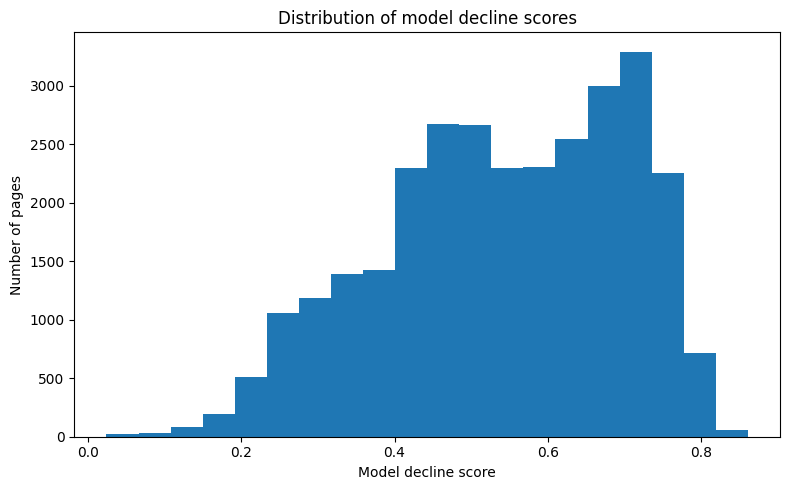

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    queue["model_decline_score"],
    bins=20
)

plt.xlabel("Model decline score")
plt.ylabel("Number of pages")
plt.title("Distribution of model decline scores")

plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.